In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import models, layers

In [2]:
data = pd.read_csv("Солодкая.csv")
data.head()

,Date,Destination,Visitor_Count,Hotel_Occupancy,Flight_Arrivals,Average_Temperature,Economic_Index,Major_Event
0,2000-01-01,Paris,152,91.861719,34,24.279758,1.098658,Festival
1,2000-01-01,Tokyo,152,77.833310,94,13.369956,0.833709,Festival
2,2000-01-01,New York,153,88.322903,41,-2.743537,1.221999,Festival
3,2000-01-01,London,207,68.493564,83,34.688462,1.117482,Exhibition
4,2000-01-01,Berlin,107,80.990257,68,15.990986,0.899861,Exhibition


In [3]:
print(data.head())
print(data.shape)
print(data.dtypes)
print(data.isnull().sum())

         Date Destination  Visitor_Count  Hotel_Occupancy  Flight_Arrivals  \
0  2000-01-01       Paris            152        91.861719               34   
1  2000-01-01       Tokyo            152        77.833310               94   
2  2000-01-01    New York            153        88.322903               41   
3  2000-01-01      London            207        68.493564               83   
4  2000-01-01      Berlin            107        80.990257               68   

   Average_Temperature  Economic_Index Major_Event  
0            24.279758        1.098658    Festival  
1            13.369956        0.833709    Festival  
2            -2.743537        1.221999    Festival  
3            34.688462        1.117482  Exhibition  
4            15.990986        0.899861  Exhibition  
(29220, 8)
Date                       str
Destination                str
Visitor_Count            int64
Hotel_Occupancy        float64
Flight_Arrivals          int64
Average_Temperature    float64
Economic_Index  

In [4]:
data['Date'] = pd.to_datetime(data['Date'])

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.dayofweek

data.head()

,Date,Destination,Visitor_Count,Hotel_Occupancy,Flight_Arrivals,Average_Temperature,Economic_Index,Major_Event,Year,Month,Day,DayOfWeek
0,2000-01-01,Paris,152,91.861719,34,24.279758,1.098658,Festival,2000,1,1,5
1,2000-01-01,Tokyo,152,77.833310,94,13.369956,0.833709,Festival,2000,1,1,5
2,2000-01-01,New York,153,88.322903,41,-2.743537,1.221999,Festival,2000,1,1,5
3,2000-01-01,London,207,68.493564,83,34.688462,1.117482,Exhibition,2000,1,1,5
4,2000-01-01,Berlin,107,80.990257,68,15.990986,0.899861,Exhibition,2000,1,1,5


In [5]:
data = data.drop('Date', axis=1)

In [6]:
data = pd.get_dummies(data, columns=['Destination', 'Major_Event'], drop_first=True)
data.head()

,Visitor_Count,Hotel_Occupancy,Flight_Arrivals,Average_Temperature,Economic_Index,Year,Month,Day,DayOfWeek,Destination_London,Destination_New York,Destination_Paris,Destination_Tokyo,Major_Event_Cultural Event,Major_Event_Exhibition,Major_Event_Festival
0,152,91.861719,34,24.279758,1.098658,2000,1,1,5,False,False,True,False,False,False,True
1,152,77.833310,94,13.369956,0.833709,2000,1,1,5,False,False,False,True,False,False,True
2,153,88.322903,41,-2.743537,1.221999,2000,1,1,5,False,True,False,False,False,False,True
3,207,68.493564,83,34.688462,1.117482,2000,1,1,5,True,False,False,False,False,True,False
4,107,80.990257,68,15.990986,0.899861,2000,1,1,5,False,False,False,False,False,True,False


In [7]:
print(data.dtypes)
print(data.shape)

Visitor_Count                   int64
Hotel_Occupancy               float64
Flight_Arrivals                 int64
Average_Temperature           float64
Economic_Index                float64
Year                            int32
Month                           int32
Day                             int32
DayOfWeek                       int32
Destination_London               bool
Destination_New York             bool
Destination_Paris                bool
Destination_Tokyo                bool
Major_Event_Cultural Event       bool
Major_Event_Exhibition           bool
Major_Event_Festival             bool
dtype: object
(29220, 16)


In [8]:
X = data.drop('Visitor_Count', axis=1)
y = data['Visitor_Count']

print(X.head())
print(y.head())

   Hotel_Occupancy  Flight_Arrivals  Average_Temperature  Economic_Index  \
0        91.861719               34            24.279758        1.098658   
1        77.833310               94            13.369956        0.833709   
2        88.322903               41            -2.743537        1.221999   
3        68.493564               83            34.688462        1.117482   
4        80.990257               68            15.990986        0.899861   

   Year  Month  Day  DayOfWeek  Destination_London  Destination_New York  \
0  2000      1    1          5               False                 False   
1  2000      1    1          5               False                 False   
2  2000      1    1          5               False                  True   
3  2000      1    1          5                True                 False   
4  2000      1    1          5               False                 False   

   Destination_Paris  Destination_Tokyo  Major_Event_Cultural Event  \
0              

In [9]:
X = X.astype('float32').values
y = y.astype('float32').values

print(X.shape)
print(y.shape)

(29220, 15)
(29220,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (23376, 15)
Размер X_test: (5844, 15)
Размер y_train: (23376,)
Размер y_test: (5844,)


In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

In [13]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 11599.8154 - mae: 86.7960 - val_loss: 5387.3496 - val_mae: 63.2235
Epoch 2/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5315.1445 - mae: 62.8190 - val_loss: 5317.2109 - val_mae: 62.9304
Epoch 3/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5274.0513 - mae: 62.6469 - val_loss: 5301.4863 - val_mae: 62.9158
Epoch 4/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5253.8462 - mae: 62.5460 - val_loss: 5296.8091 - val_mae: 62.8801
Epoch 5/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5238.7812 - mae: 62.4933 - val_loss: 5292.4087 - val_mae: 62.8849
Epoch 6/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5229.9966 - mae: 62.4177 - val_loss: 5301.9028 - val_mae: 62.9274
Epoch 7/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5224.7681 - mae: 62.3881 - val_loss: 5276.3989 - val_mae: 62.8038
Epoch 8/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5218.8916 - mae: 62.3806 - val_loss: 5300.5020 - val_mae:

In [15]:
loss, mae = model.evaluate(X_test, y_test)
print("Loss (MSE):", loss)
print("MAE:", mae)

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5276.5469 - mae: 62.8517  
Loss (MSE): 5276.546875
MAE: 62.85165786743164


In [16]:
predictions = model.predict(X_test)

print("Прогнозы:")
print(predictions[:10])

print("Реальные значения:")
print(y_test[:10])

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step
Прогнозы:
[[164.61841]
 [175.62315]
 [157.22337]
 [173.49442]
 [167.34618]
 [175.77151]
 [172.58093]
 [174.95218]
 [181.98868]
 [174.99901]]
Реальные значения:
[233. 259. 182. 206. 228. 176. 190. 103.  95.  54.]


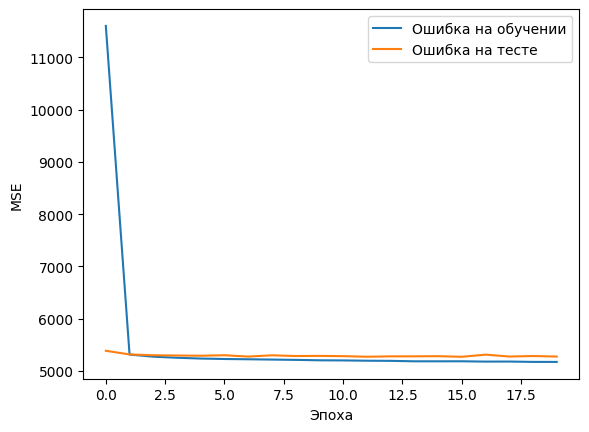

In [17]:
plt.plot(history.history['loss'], label='Ошибка на обучении')
plt.plot(history.history['val_loss'], label='Ошибка на тесте')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

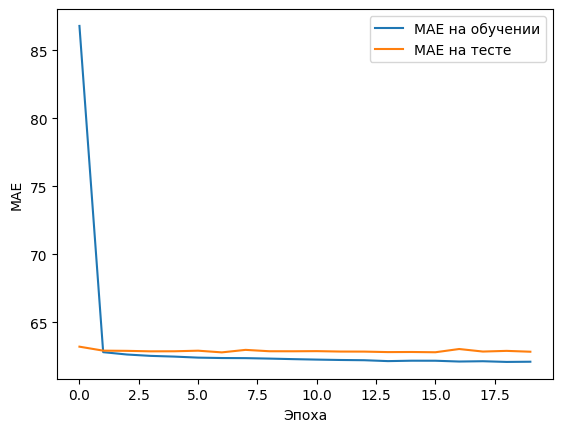

In [18]:
plt.plot(history.history['mae'], label='MAE на обучении')
plt.plot(history.history['val_mae'], label='MAE на тесте')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.show()

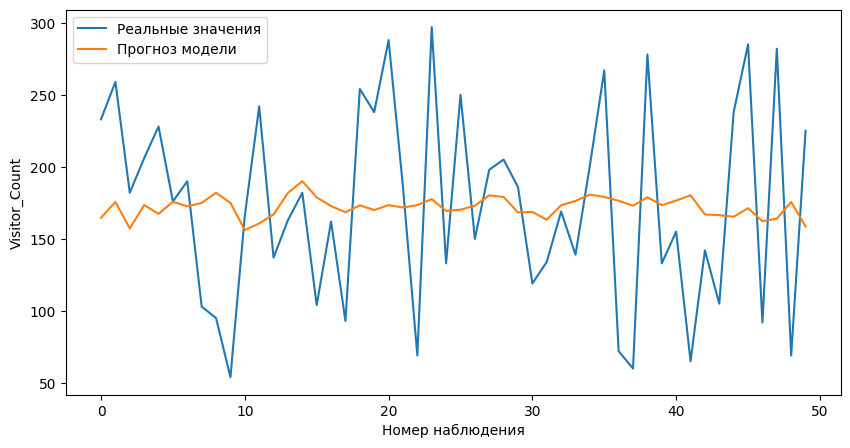

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(y_test[:50], label='Реальные значения')
plt.plot(predictions[:50], label='Прогноз модели')
plt.xlabel('Номер наблюдения')
plt.ylabel('Visitor_Count')
plt.legend()
plt.show()

используется регрессия, предсказывается не класс, а числовое значение спроса